In [90]:
base_dir = Path(__file__).parent / 'data' / 'buoys'

NameError: name '__file__' is not defined

In [87]:
def download_buoy_data(buoy_id, years, base_dir):
    """
    Download directional wave spectra data for specified buoy and years.
    
    Parameters:
    -----------
    buoy_id : str
        Buoy identifier (e.g., '41001')
    years : list
        List of years to download data for
    base_dir : str or Path
        Base directory for buoy data ('/Users/jenmontano/Duke/data/buoys')
    """
    import requests
    from pathlib import Path
    import gzip
    import shutil
    
    # Convert base_dir to Path object if it's a string
    base_dir = Path(base_dir)
    buoy_id = str(buoy_id)
    
    # Coefficients and their corresponding file identifiers and URLs
    coefficients = {
        'd': {
            'name': 'alpha1',
            'url': f'https://www.ndbc.noaa.gov/data/historical/swdir'
        },
        'i': {
            'name': 'alpha2',
            'url': f'https://www.ndbc.noaa.gov/data/historical/swdir2'
        },
        'j': {
            'name': 'r1',
            'url': f'https://www.ndbc.noaa.gov/data/historical/swr1'
        },
        'k': {
            'name': 'r2',
            'url': f'https://www.ndbc.noaa.gov/data/historical/swr2'
        },
        'w': {
            'name': 'c11',
            'url': f'https://www.ndbc.noaa.gov/data/historical/swden'
        }
    }
    
    # Create buoy-specific directory and its directional_spectra subdirectory
    buoy_dir = base_dir / buoy_id
    dir_spectra_dir = buoy_dir / 'directional_spectra'
    dir_spectra_dir.mkdir(parents=True, exist_ok=True)
    
    for year in years:
        for coef, info in coefficients.items():
            # Construct filename and URL
            filename = f"{buoy_id}{coef}{year}.txt.gz"
            url = f"{info['url']}/{filename}"
            
            # Local path for saving the file
            save_path = dir_spectra_dir / filename
            
            try:
                print(f"Downloading {info['name']} data for {year}...")
                response = requests.get(url, stream=True)
                response.raise_for_status()  # Raise an error for bad status codes
                
                # Save the compressed file
                with open(save_path, 'wb') as f:
                    shutil.copyfileobj(response.raw, f)
                    
                print(f"Successfully downloaded {filename}")
                
            except requests.exceptions.RequestException as e:
                print(f"Error downloading {filename}: {e}")
                print(f"Attempted URL: {url}")
                continue

# Example usage:
if __name__ == "__main__":
    # Define parameters
    buoys_id =  ['41002','41004', '41013','41025']
    years = range(2012, 2024)  # Adjust the range as needed
  
    
    # Download the data
    for buoy_id in buoys_id:
     download_buoy_data(buoy_id, years, base_dir)

Successfully downloaded 41002d2012.txt.gz
Successfully downloaded 41002i2012.txt.gz
Successfully downloaded 41002j2012.txt.gz
Successfully downloaded 41002k2012.txt.gz
Successfully downloaded 41002w2012.txt.gz
Successfully downloaded 41002d2013.txt.gz
Successfully downloaded 41002i2013.txt.gz
Successfully downloaded 41002j2013.txt.gz
Successfully downloaded 41002k2013.txt.gz
Successfully downloaded 41002w2013.txt.gz
Successfully downloaded 41002d2014.txt.gz
Successfully downloaded 41002i2014.txt.gz
Successfully downloaded 41002j2014.txt.gz
Successfully downloaded 41002k2014.txt.gz
Successfully downloaded 41002w2014.txt.gz
Successfully downloaded 41002d2015.txt.gz
Successfully downloaded 41002i2015.txt.gz
Successfully downloaded 41002j2015.txt.gz
Successfully downloaded 41002k2015.txt.gz
Successfully downloaded 41002w2015.txt.gz
Successfully downloaded 41002d2016.txt.gz
Successfully downloaded 41002i2016.txt.gz
Successfully downloaded 41002j2016.txt.gz
Successfully downloaded 41002k2016

KeyboardInterrupt: 

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gzip
from datetime import datetime

# Define paths
base_dir = Path('/Users/jenmontano/Duke/data/buoys/')



def calculate_directional_spectrum(C11, freq, alpha1, alpha2, r1, r2):
    """
    Calculate normalized directional wave spectrum.
    """
    # Create angle array (0 to 360 degrees)
    angles = np.linspace(0, 2*np.pi, 360)
    
    # Create meshgrid for frequency and direction
    angle_mesh, freq_mesh = np.meshgrid(angles, freq)
    
    # Convert angles to radians
    alpha1_rad = np.deg2rad(alpha1)
    alpha2_rad = np.deg2rad(alpha2)
    
    # Convert r1 and r2 from percentages to decimals
    r1 = np.array(r1) / 100
    r2 = np.array(r2) / 100

    # Initialize spectrum array
    E = np.zeros((len(freq), len(angles)))
    
    # Calculate directional spectrum for each frequency
    for i in range(len(freq)):
        # Compute spreading function D(f,θ)
        D = (1 / np.pi) * (0.5 + r1[i] * np.cos(angles - alpha1_rad[i]) + r2[i] * np.cos(2 * (angles - alpha2_rad[i])))
        
        # Normalize so it integrates to 1
        D = D / np.trapz(D, angles)
        
        # Ensure non-negative values
        D[D < 0] = 0
        
        # Calculate full directional spectrum
        E[i, :] = C11[i] * D
    
    return E.T, freq_mesh.T, angle_mesh.T

def read_directional_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        header = f.readline().strip()
        freqs = [float(x) for x in header.split()[5:]]
        
        data, dates = [], []
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                year, month, day, hour, minute = map(int, parts[:5])
                values = [float(x) for x in parts[5:]]
                if len(values) == len(freqs):
                    dates.append(datetime(year, month, day, hour, minute))
                    data.append(values)
    
    return pd.DataFrame(data, index=dates, columns=freqs)

def read_spectra_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        header = f.readline().strip()
        freqs = [float(x) for x in header.split()[5:]]
        
        data, dates = [], []
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                year, month, day, hour, minute = map(int, parts[:5])
                values = [float(x) for x in parts[5:]]
                if len(values) == len(freqs):
                    dates.append(datetime(year, month, day, hour, minute))
                    data.append(values)
    
    return pd.DataFrame(data, index=dates, columns=freqs)

def get_season(month):
    return {12: 'DJF', 1: 'DJF', 2: 'DJF',
            3: 'MAM', 4: 'MAM', 5: 'MAM',
            6: 'JJA', 7: 'JJA', 8: 'JJA',
            9: 'SON', 10: 'SON', 11: 'SON'}[month]

def calculate_averages(df):
    # Convert all columns to numeric, coercing errors to NaN
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    # Add season column back
    numeric_df['season'] = df.index.month.map(get_season)
    
    # Calculate monthly average
    monthly_avg = numeric_df.drop('season', axis=1).groupby(numeric_df.index.month).mean()
    # Calculate seasonal average
    seasonal_avg = numeric_df.drop('season', axis=1).groupby(numeric_df['season']).mean()
    # Calculate annual average
    annual_avg = numeric_df.drop('season', axis=1).mean()
    
    return monthly_avg, seasonal_avg, annual_avg

def plot_directional_spectrum(E, freq_mesh, angle_mesh, title, save_path):
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, projection='polar')
    pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
    plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location('N')
    plt.title(title)
    plt.savefig(save_path)
 
def main():
    dir_spectra_dir = base_dir /{buoy_id} / 'directional_spectra'
    # Read the data files
    alpha1_df = read_directional_file(dir_spectra_dir / '{buoy_id}d{year}.txt.gz')
    alpha2_df = read_directional_file(dir_spectra_dir / '41001i2012.txt.gz')
    r1_df = read_directional_file(dir_spectra_dir / '41001j2012.txt.gz')
    r2_df = read_directional_file(dir_spectra_dir / '41001k2012.txt.gz')
    c11_df = read_spectra_file(dir_spectra_dir / '41001w2012.txt.gz')
    
    # Convert all dataframes to numeric
    r1_df = r1_df.apply(pd.to_numeric, errors='coerce')
    r2_df = r2_df.apply(pd.to_numeric, errors='coerce')
    alpha1_df = alpha1_df.apply(pd.to_numeric, errors='coerce')
    alpha2_df = alpha2_df.apply(pd.to_numeric, errors='coerce')
    c11_df = c11_df.apply(pd.to_numeric, errors='coerce')
    
    # Get frequencies from the columns
    freqs = np.array([float(col) for col in r1_df.columns])
    
    # Create a figure for monthly spectra
    fig_monthly, axes_monthly = plt.subplots(3, 4, figsize=(20, 15), subplot_kw={'projection': 'polar'})
    fig_monthly.suptitle('Monthly Directional Spectra', fontsize=16, y=0.95)
    
    # Calculate and plot monthly averages
    for month in range(1, 13):
        try:
            # Get monthly averages and convert to numpy arrays
            r1_monthly = r1_df.groupby(r1_df.index.month).mean().loc[month].values
            r2_monthly = r2_df.groupby(r2_df.index.month).mean().loc[month].values
            alpha1_monthly = alpha1_df.groupby(alpha1_df.index.month).mean().loc[month].values
            alpha2_monthly = alpha2_df.groupby(alpha2_df.index.month).mean().loc[month].values
            c11_monthly = c11_df.groupby(c11_df.index.month).mean().loc[month].values
            
            E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                c11_monthly, freqs, alpha1_monthly, alpha2_monthly, r1_monthly, r2_monthly
            )
            
            # Plot in the appropriate subplot
            row = (month - 1) // 4
            col = (month - 1) % 4
            ax = axes_monthly[row, col]
            
            pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
            ax.set_theta_direction(-1)
            ax.set_theta_zero_location('N')
            ax.set_title(f'Month {month}')
            
            # Make frequency labels white
            ax.tick_params(axis='y', colors='white')
            ax.yaxis.label.set_color('white')
            
        except KeyError:
            print(f"No data available for month {month}")
            continue
    
    # Add colorbar to the monthly plot
    fig_monthly.subplots_adjust(right=0.85)
    cbar_ax = fig_monthly.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig_monthly.colorbar(pcm, cax=cbar_ax, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.savefig('monthly_directional_spectra.png', bbox_inches='tight', dpi=300)
  
    
    # Create a figure for seasonal spectra
    fig_seasonal, axes_seasonal = plt.subplots(2, 2, figsize=(15, 12), subplot_kw={'projection': 'polar'})
    fig_seasonal.suptitle('Seasonal Directional Spectra', fontsize=16, y=0.95)
    
    # Calculate and plot seasonal averages
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    for i, season in enumerate(seasons):
        try:
            # Get seasonal averages and convert to numpy arrays
            r1_seasonal = r1_df.groupby(r1_df.index.month.map(get_season)).mean().loc[season].values
            r2_seasonal = r2_df.groupby(r2_df.index.month.map(get_season)).mean().loc[season].values
            alpha1_seasonal = alpha1_df.groupby(alpha1_df.index.month.map(get_season)).mean().loc[season].values
            alpha2_seasonal = alpha2_df.groupby(alpha2_df.index.month.map(get_season)).mean().loc[season].values
            c11_seasonal = c11_df.groupby(c11_df.index.month.map(get_season)).mean().loc[season].values
            
            E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                c11_seasonal, freqs, alpha1_seasonal, alpha2_seasonal, r1_seasonal, r2_seasonal
            )
            
            # Plot in the appropriate subplot
            row = i // 2
            col = i % 2
            ax = axes_seasonal[row, col]
            
            pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
            ax.set_theta_direction(-1)
            ax.set_theta_zero_location('N')
            ax.set_title(season)
            
            # Make frequency labels white
            ax.tick_params(axis='y', colors='white')
            ax.yaxis.label.set_color('white')
            
        except KeyError:
            print(f"No data available for season {season}")
            continue
    
    # Add colorbar to the seasonal plot
    fig_seasonal.subplots_adjust(right=0.85)
    cbar_ax = fig_seasonal.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig_seasonal.colorbar(pcm, cax=cbar_ax, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.savefig('seasonal_directional_spectra.png', bbox_inches='tight', dpi=300)

    
    # Calculate and plot annual average (single plot)
    r1_annual = r1_df.mean().values
    r2_annual = r2_df.mean().values
    alpha1_annual = alpha1_df.mean().values
    alpha2_annual = alpha2_df.mean().values
    c11_annual = c11_df.mean().values
    
    E, freq_mesh, angle_mesh = calculate_directional_spectrum(
        c11_annual, freqs, alpha1_annual, alpha2_annual, r1_annual, r2_annual
    )
    
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, projection='polar')
    pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location('N')
    
    # Make frequency labels white
    ax.tick_params(axis='y', colors='white')
    ax.yaxis.label.set_color('white')
    
    # Add colorbar to the annual plot
    cbar = plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.title('Annual Directional Spectrum')
    plt.savefig('annual_directional_spectrum.png', bbox_inches='tight', dpi=300)
  

if __name__ == "__main__":
    main()




NameError: name '__file__' is not defined

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gzip
from datetime import datetime
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Define paths
base_dir = Path('/Users/jenmontano/Duke/data/buoys/')

def calculate_directional_spectrum(C11, freq, alpha1, alpha2, r1, r2):
    """
    Calculate normalized directional wave spectrum.
    """
    # Create angle array (0 to 360 degrees)
    angles = np.linspace(0, 2*np.pi, 360)
    
    # Create meshgrid for frequency and direction
    angle_mesh, freq_mesh = np.meshgrid(angles, freq)
    
    # Convert angles to radians
    alpha1_rad = np.deg2rad(alpha1)
    alpha2_rad = np.deg2rad(alpha2)
    
    # Convert r1 and r2 from percentages to decimals
    r1 = np.array(r1) / 100
    r2 = np.array(r2) / 100

    # Initialize spectrum array
    E = np.zeros((len(freq), len(angles)))
    
    # Calculate directional spectrum for each frequency
    for i in range(len(freq)):
        # Compute spreading function D(f,θ)
        D = (1 / np.pi) * (0.5 + r1[i] * np.cos(angles - alpha1_rad[i]) + r2[i] * np.cos(2 * (angles - alpha2_rad[i])))
        
        # Normalize so it integrates to 1
        D = D / np.trapz(D, angles)
        
        # Ensure non-negative values
        D[D < 0] = 0
        
        # Calculate full directional spectrum
        E[i, :] = C11[i] * D
    
    return E.T, freq_mesh.T, angle_mesh.T

def read_directional_file(file_path):
    """Read directional spectra file and return DataFrame with datetime index and frequency columns"""
    logging.info(f"Reading file: {file_path}")
    try:
        with gzip.open(file_path, 'rt') as f:
            # Read header line
            header = f.readline().strip()
            logging.info(f"Header: {header}")
            
            # Parse frequencies from header
            try:
                freqs = [float(x) for x in header.split()[5:]]
                logging.info(f"Found {len(freqs)} frequencies")
            except (ValueError, IndexError) as e:
                logging.error(f"Error parsing frequencies: {e}")
                return pd.DataFrame()
            
            # Read data
            data = []
            dates = []
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        year, month, day, hour, minute = map(int, parts[:5])
                        values = [float(x) for x in parts[5:]]
                        if len(values) == len(freqs):
                            dates.append(datetime(year, month, day, hour, minute))
                            data.append(values)
                    except (ValueError, IndexError) as e:
                        logging.error(f"Error parsing line: {e}")
                        continue
            
            if not data:
                logging.warning("No valid data points found in file")
                return pd.DataFrame()
            
            df = pd.DataFrame(data, index=dates, columns=freqs)
            logging.info(f"Created DataFrame with shape: {df.shape}")
            return df
            
    except Exception as e:
        logging.error(f"Error reading file {file_path}: {str(e)}")
        return pd.DataFrame()

def read_spectra_file(file_path):
    """Read the C11 spectra file"""
    logging.info(f"Reading file: {file_path}")
    try:
        with gzip.open(file_path, 'rt') as f:
            # Skip header lines until we find the data
            for line in f:
                if line.startswith('#'):
                    continue
                # First non-comment line contains frequencies
                try:
                    freqs = [float(x) for x in line.strip().split()]
                    logging.info(f"Found {len(freqs)} frequencies")
                    break
                except ValueError as e:
                    logging.error(f"Error parsing frequencies: {e}")
                    return pd.DataFrame()
            
            # Read the data
            data = []
            dates = []
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        year, month, day, hour, minute = map(int, parts[:5])
                        values = [float(x) for x in parts[5:]]
                        if len(values) == len(freqs):
                            dates.append(datetime(year, month, day, hour, minute))
                            data.append(values)
                    except (ValueError, IndexError) as e:
                        logging.error(f"Error parsing line: {e}")
                        continue
            
            if not data:
                logging.warning("No valid data points found in file")
                return pd.DataFrame()
            
            df = pd.DataFrame(data, index=dates, columns=freqs)
            logging.info(f"Created DataFrame with shape: {df.shape}")
            return df
            
    except Exception as e:
        logging.error(f"Error reading file {file_path}: {str(e)}")
        return pd.DataFrame()

def get_season(month):
    """Return season based on month"""
    return {12: 'DJF', 1: 'DJF', 2: 'DJF',
            3: 'MAM', 4: 'MAM', 5: 'MAM',
            6: 'JJA', 7: 'JJA', 8: 'JJA',
            9: 'SON', 10: 'SON', 11: 'SON'}[month]

def process_year(buoy_id, year):
    """Process data for a single buoy and year"""
    logging.info(f"Processing buoy {buoy_id} for year {year}")
    
    # Create paths for this year's files
    dir_spectra_dir = base_dir / buoy_id / 'directional_spectra'
    alpha1_path = dir_spectra_dir / f'{buoy_id}d{year}.txt.gz'
    alpha2_path = dir_spectra_dir / f'{buoy_id}i{year}.txt.gz'
    r1_path = dir_spectra_dir / f'{buoy_id}j{year}.txt.gz'
    r2_path = dir_spectra_dir / f'{buoy_id}k{year}.txt.gz'
    c11_path = dir_spectra_dir / f'{buoy_id}w{year}.txt.gz'
    
    # Check if all required files exist
    required_files = [alpha1_path, alpha2_path, r1_path, r2_path, c11_path]
    missing_files = [f for f in required_files if not f.exists()]
    
    if missing_files:
        logging.warning(f"Missing files for {buoy_id} {year}: {[f.name for f in missing_files]}")
        return None
    
    try:
        # Read all data files
        alpha1_df = read_directional_file(alpha1_path)
        alpha2_df = read_directional_file(alpha2_path)
        r1_df = read_directional_file(r1_path)
        r2_df = read_directional_file(r2_path)
        c11_df = read_spectra_file(c11_path)
        
        if any(df.empty for df in [alpha1_df, alpha2_df, r1_df, r2_df, c11_df]):
            logging.error(f"Failed to read one or more data files for {buoy_id} {year}")
            return None
        
        # Convert all dataframes to numeric
        r1_df = r1_df.apply(pd.to_numeric, errors='coerce')
        r2_df = r2_df.apply(pd.to_numeric, errors='coerce')
        alpha1_df = alpha1_df.apply(pd.to_numeric, errors='coerce')
        alpha2_df = alpha2_df.apply(pd.to_numeric, errors='coerce')
        c11_df = c11_df.apply(pd.to_numeric, errors='coerce')
        
        # Get frequencies from the columns
        freqs = np.array([float(col) for col in r1_df.columns])
        
        # Create output directory
        output_dir = base_dir / "processed" / buoy_id / str(year)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Process monthly data
        for month in range(1, 13):
            try:
                # Get monthly averages
                r1_monthly = r1_df.groupby(r1_df.index.month).mean().loc[month].values
                r2_monthly = r2_df.groupby(r2_df.index.month).mean().loc[month].values
                alpha1_monthly = alpha1_df.groupby(alpha1_df.index.month).mean().loc[month].values
                alpha2_monthly = alpha2_df.groupby(alpha2_df.index.month).mean().loc[month].values
                c11_monthly = c11_df.groupby(c11_df.index.month).mean().loc[month].values
                
                # Calculate directional spectrum
                E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                    c11_monthly, freqs, alpha1_monthly, alpha2_monthly, r1_monthly, r2_monthly
                )
                
                # Plot and save
                plt.figure(figsize=(10, 8))
                ax = plt.subplot(111, projection='polar')
                pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
                ax.set_theta_direction(-1)
                ax.set_theta_zero_location('N')
                plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
                plt.title(f'Directional Spectrum - Month {month} - {buoy_id} {year}')
                plt.savefig(output_dir / f'directional_spectrum_month_{month}.png')
                plt.close()
                
            except KeyError:
                logging.warning(f"No data available for month {month}")
                continue
        
        # Process seasonal data
        seasons = ['DJF', 'MAM', 'JJA', 'SON']
        for season in seasons:
            try:
                # Get seasonal averages
                r1_seasonal = r1_df.groupby(r1_df.index.month.map(get_season)).mean().loc[season].values
                r2_seasonal = r2_df.groupby(r2_df.index.month.map(get_season)).mean().loc[season].values
                alpha1_seasonal = alpha1_df.groupby(alpha1_df.index.month.map(get_season)).mean().loc[season].values
                alpha2_seasonal = alpha2_df.groupby(alpha2_df.index.month.map(get_season)).mean().loc[season].values
                c11_seasonal = c11_df.groupby(c11_df.index.month.map(get_season)).mean().loc[season].values
                
                # Calculate directional spectrum
                E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                    c11_seasonal, freqs, alpha1_seasonal, alpha2_seasonal, r1_seasonal, r2_seasonal
                )
                
                # Plot and save
                plt.figure(figsize=(10, 8))
                ax = plt.subplot(111, projection='polar')
                pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
                ax.set_theta_direction(-1)
                ax.set_theta_zero_location('N')
                plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
                plt.title(f'Directional Spectrum - {season} - {buoy_id} {year}')
                plt.savefig(output_dir / f'directional_spectrum_{season.lower()}.png')
                plt.close()
                
            except KeyError:
                logging.warning(f"No data available for season {season}")
                continue
        
        # Process annual data
        r1_annual = r1_df.mean().values
        r2_annual = r2_df.mean().values
        alpha1_annual = alpha1_df.mean().values
        alpha2_annual = alpha2_df.mean().values
        c11_annual = c11_df.mean().values
        
        E, freq_mesh, angle_mesh = calculate_directional_spectrum(
            c11_annual, freqs, alpha1_annual, alpha2_annual, r1_annual, r2_annual
        )
        
        plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, projection='polar')
        pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
        ax.set_theta_direction(-1)
        ax.set_theta_zero_location('N')
        plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
        plt.title(f'Directional Spectrum - Annual - {buoy_id} {year}')
        plt.savefig(output_dir / 'directional_spectrum_annual.png')
        plt.close()
        
        logging.info(f"Successfully processed {buoy_id} {year}")
        return True
        
    except Exception as e:
        logging.error(f"Error processing {buoy_id} {year}: {str(e)}")
        return None

def main():
    """Main processing function"""
    logging.info(f"Processing {len(BUOYS_TO_PROCESS)} specified buoys")
    
    # Process each specified buoy
    for buoy_id in BUOYS_TO_PROCESS:
        logging.info(f"Processing buoy {buoy_id}")
    
    logging.info(f"Found {len(buoy_ids)} buoys to process")
    
    # Process each buoy
    for buoy_id in buoy_ids:
        logging.info(f"Processing buoy {buoy_id}")
        
        # Try years from 2012 to 2023
        for year in range(2012, 2024):
            result = process_year(buoy_id, year)
            if result:
                logging.info(f"Successfully processed {buoy_id} {year}")
            else:
                logging.warning(f"Failed to process {buoy_id} {year}")

if __name__ == "__main__":
    main() 

2025-04-02 15:57:09,841 - INFO - Found 19 buoys to process
2025-04-02 15:57:09,843 - INFO - Processing buoy 41065
2025-04-02 15:57:09,843 - INFO - Processing buoy 41065 for year 2012
2025-04-02 15:57:09,844 - WARNING - Missing files for 41065 2012: ['41065d2012.txt.gz', '41065i2012.txt.gz', '41065j2012.txt.gz', '41065k2012.txt.gz', '41065w2012.txt.gz']
2025-04-02 15:57:09,844 - WARNING - Failed to process 41065 2012
2025-04-02 15:57:09,845 - INFO - Processing buoy 41065 for year 2013
2025-04-02 15:57:09,845 - WARNING - Missing files for 41065 2013: ['41065d2013.txt.gz', '41065i2013.txt.gz', '41065j2013.txt.gz', '41065k2013.txt.gz', '41065w2013.txt.gz']
2025-04-02 15:57:09,845 - WARNING - Failed to process 41065 2013
2025-04-02 15:57:09,845 - INFO - Processing buoy 41065 for year 2014
2025-04-02 15:57:09,846 - WARNING - Missing files for 41065 2014: ['41065d2014.txt.gz', '41065i2014.txt.gz', '41065j2014.txt.gz', '41065k2014.txt.gz', '41065w2014.txt.gz']
2025-04-02 15:57:09,846 - WARNING

KeyboardInterrupt: 

No data available for month 1
No data available for month 2
No data available for month 3
No data available for month 4
No data available for month 5
No data available for month 6


/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_2093/1214960353.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D = D / np.trapz(D, angles)
/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_2093/1214960353.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D = D / np.trapz(D, angles)
/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_2093/1214960353.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D = D / np.trapz(D, angles)
/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_2093/1214960353.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D = D / np.trapz(D, angles)


No data available for season MAM


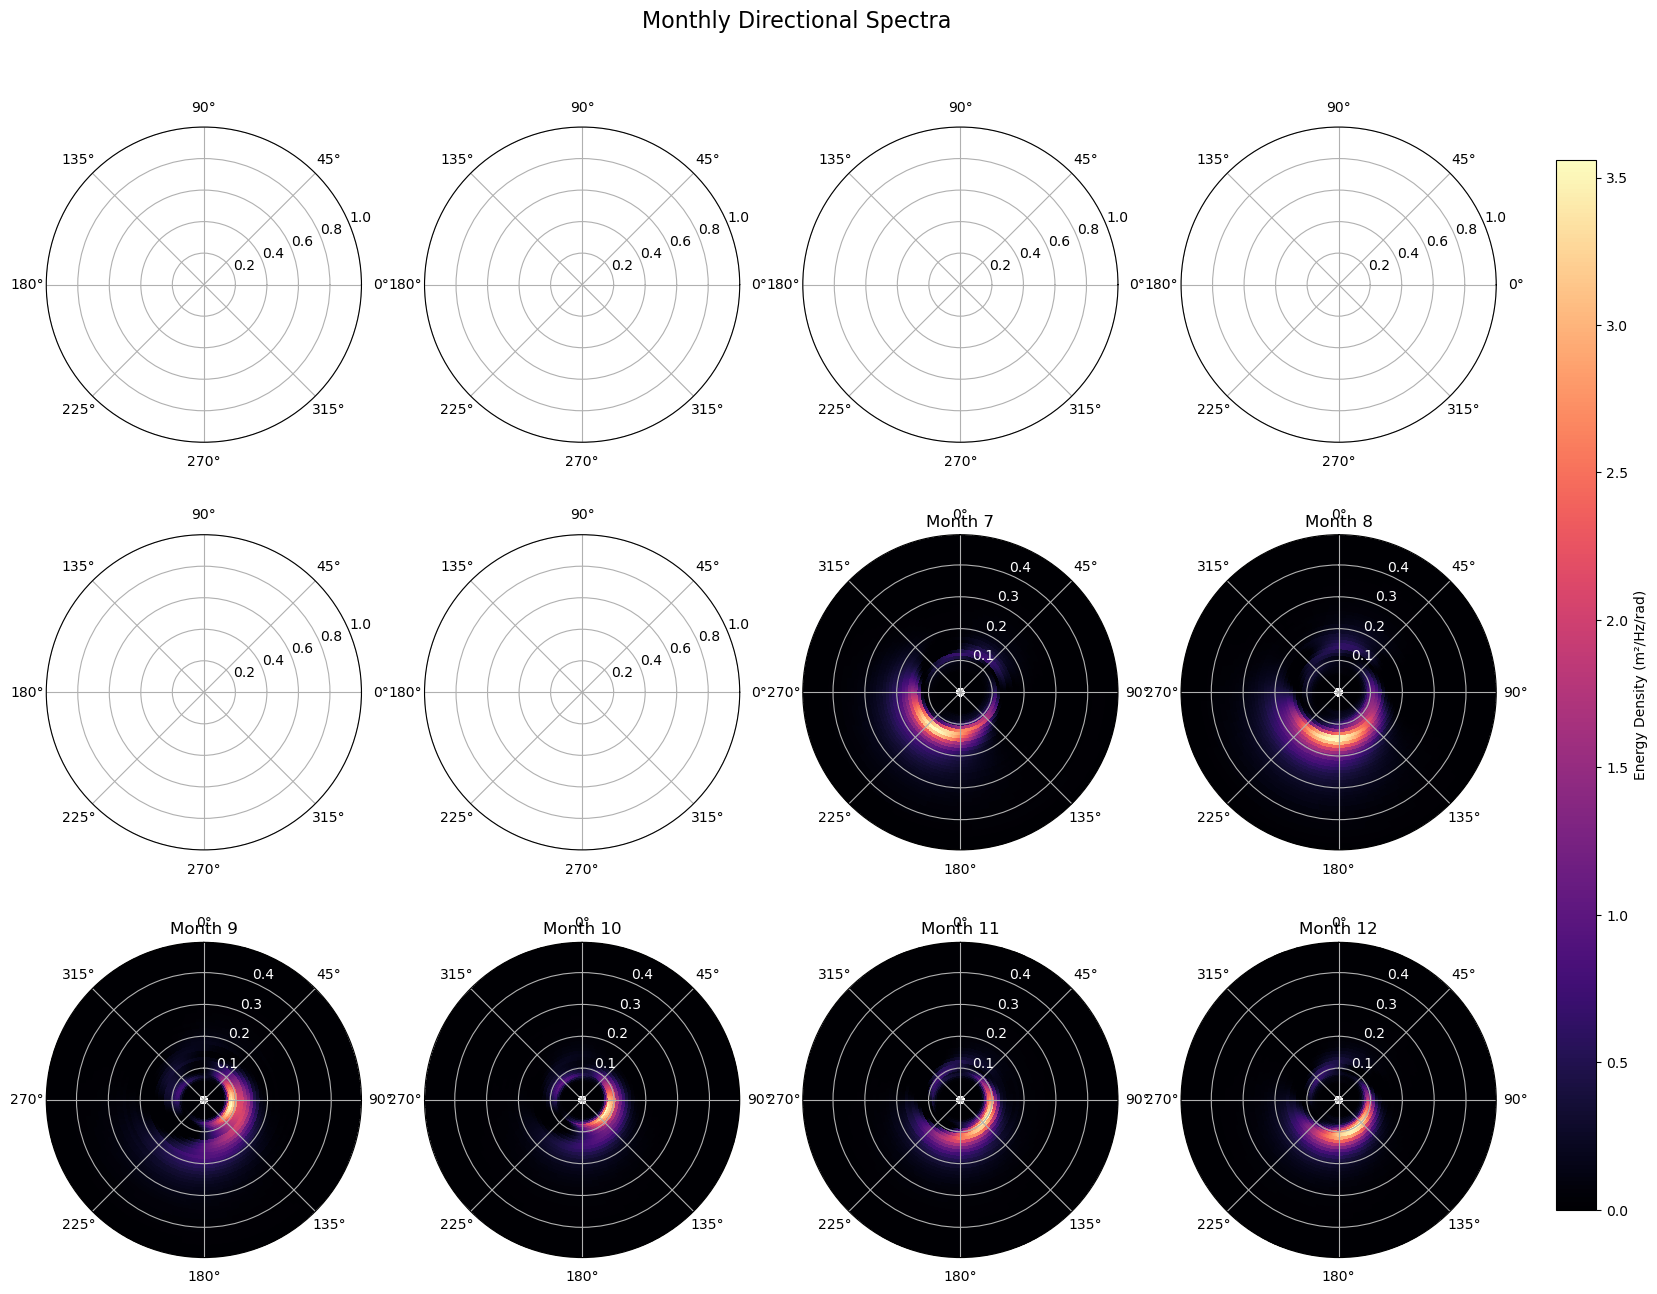

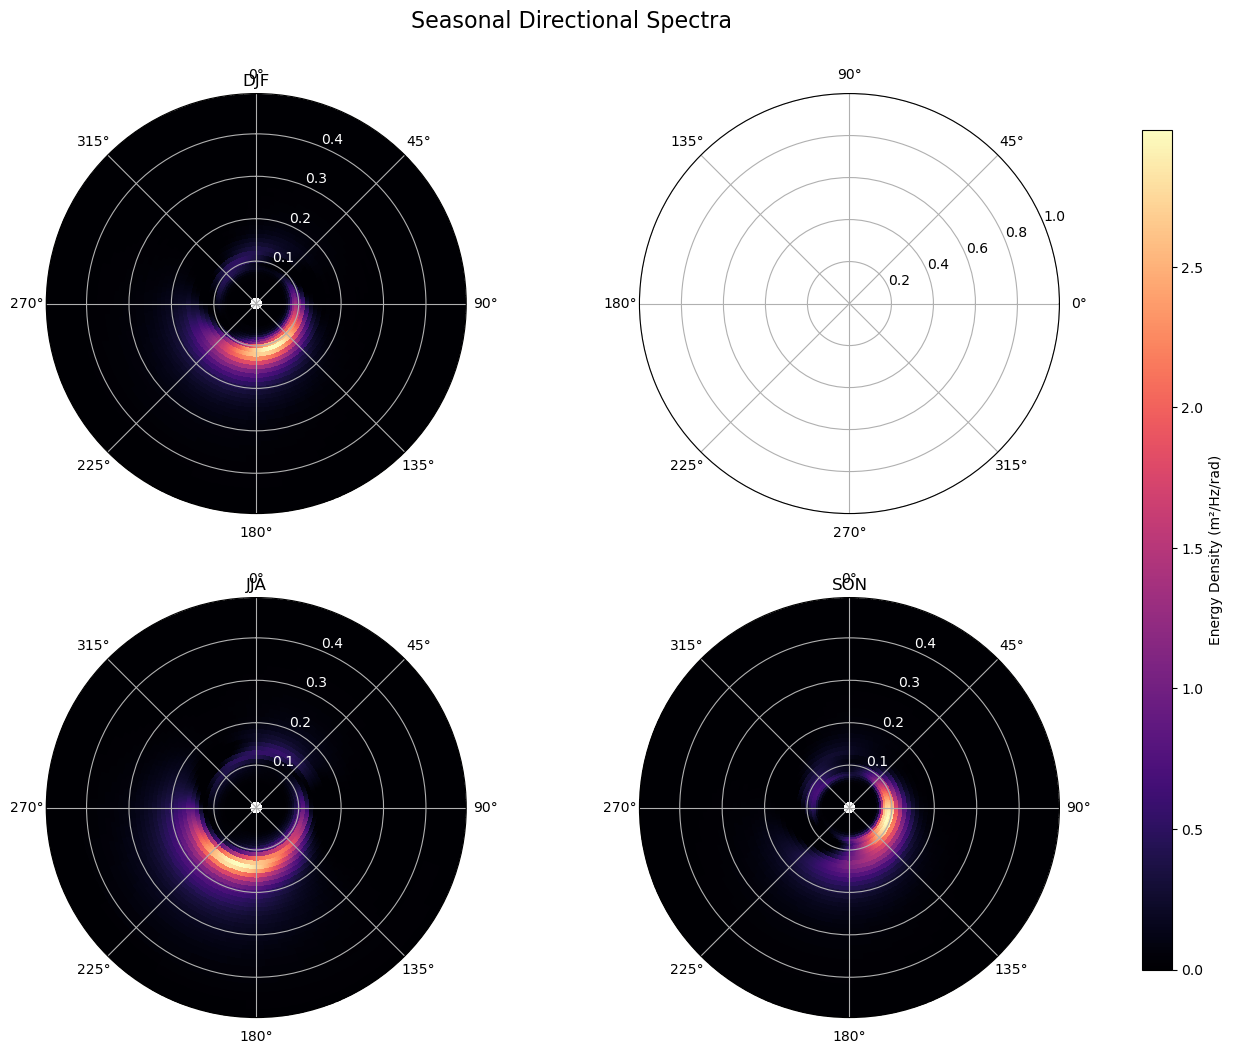

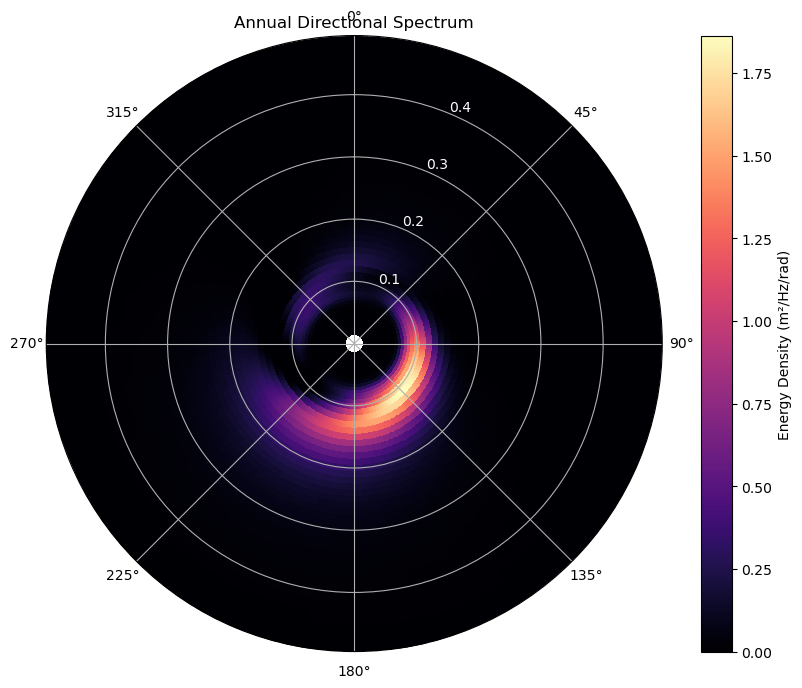

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gzip
from datetime import datetime

# Define paths
base_dir = Path('/Users/jenmontano/Duke/data/buoys/')
dir_spectra_dir = base_dir / 'directional_spectra'


def calculate_directional_spectrum(C11, freq, alpha1, alpha2, r1, r2):
    """
    Calculate normalized directional wave spectrum.
    """
    # Create angle array (0 to 360 degrees)
    angles = np.linspace(0, 2*np.pi, 360)
    
    # Create meshgrid for frequency and direction
    angle_mesh, freq_mesh = np.meshgrid(angles, freq)
    
    # Convert angles to radians
    alpha1_rad = np.deg2rad(alpha1)
    alpha2_rad = np.deg2rad(alpha2)
    
    # Convert r1 and r2 from percentages to decimals
    r1 = np.array(r1) / 100
    r2 = np.array(r2) / 100

    # Initialize spectrum array
    E = np.zeros((len(freq), len(angles)))
    
    # Calculate directional spectrum for each frequency
    for i in range(len(freq)):
        # Compute spreading function D(f,θ)
        D = (1 / np.pi) * (0.5 + r1[i] * np.cos(angles - alpha1_rad[i]) + r2[i] * np.cos(2 * (angles - alpha2_rad[i])))
        
        # Normalize so it integrates to 1
        D = D / np.trapz(D, angles)
        
        # Ensure non-negative values
        D[D < 0] = 0
        
        # Calculate full directional spectrum
        E[i, :] = C11[i] * D
    
    return E.T, freq_mesh.T, angle_mesh.T

def read_directional_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        header = f.readline().strip()
        freqs = [float(x) for x in header.split()[5:]]
        
        data, dates = [], []
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                year, month, day, hour, minute = map(int, parts[:5])
                values = [float(x) for x in parts[5:]]
                if len(values) == len(freqs):
                    dates.append(datetime(year, month, day, hour, minute))
                    data.append(values)
    
    return pd.DataFrame(data, index=dates, columns=freqs)

def read_spectra_file(file_path):
    with gzip.open(file_path, 'rt') as f:
        header = f.readline().strip()
        freqs = [float(x) for x in header.split()[5:]]
        
        data, dates = [], []
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                year, month, day, hour, minute = map(int, parts[:5])
                values = [float(x) for x in parts[5:]]
                if len(values) == len(freqs):
                    dates.append(datetime(year, month, day, hour, minute))
                    data.append(values)
    
    return pd.DataFrame(data, index=dates, columns=freqs)

def get_season(month):
    return {12: 'DJF', 1: 'DJF', 2: 'DJF',
            3: 'MAM', 4: 'MAM', 5: 'MAM',
            6: 'JJA', 7: 'JJA', 8: 'JJA',
            9: 'SON', 10: 'SON', 11: 'SON'}[month]

def calculate_averages(df):
    # Convert all columns to numeric, coercing errors to NaN
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    # Add season column back
    numeric_df['season'] = df.index.month.map(get_season)
    
    # Calculate monthly average
    monthly_avg = numeric_df.drop('season', axis=1).groupby(numeric_df.index.month).mean()
    # Calculate seasonal average
    seasonal_avg = numeric_df.drop('season', axis=1).groupby(numeric_df['season']).mean()
    # Calculate annual average
    annual_avg = numeric_df.drop('season', axis=1).mean()
    
    return monthly_avg, seasonal_avg, annual_avg

def plot_directional_spectrum(E, freq_mesh, angle_mesh, title, save_path):
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, projection='polar')
    pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
    plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location('N')
    plt.title(title)
    plt.savefig(save_path)
 
def main():
    # Read the data files
    alpha1_df = read_directional_file(dir_spectra_dir / '41001d2012.txt.gz')
    alpha2_df = read_directional_file(dir_spectra_dir / '41001i2012.txt.gz')
    r1_df = read_directional_file(dir_spectra_dir / '41001j2012.txt.gz')
    r2_df = read_directional_file(dir_spectra_dir / '41001k2012.txt.gz')
    c11_df = read_spectra_file(dir_spectra_dir / '41001w2012.txt.gz')
    
    # Convert all dataframes to numeric
    r1_df = r1_df.apply(pd.to_numeric, errors='coerce')
    r2_df = r2_df.apply(pd.to_numeric, errors='coerce')
    alpha1_df = alpha1_df.apply(pd.to_numeric, errors='coerce')
    alpha2_df = alpha2_df.apply(pd.to_numeric, errors='coerce')
    c11_df = c11_df.apply(pd.to_numeric, errors='coerce')
    
    # Get frequencies from the columns
    freqs = np.array([float(col) for col in r1_df.columns])
    
    # Create a figure for monthly spectra
    fig_monthly, axes_monthly = plt.subplots(3, 4, figsize=(20, 15), subplot_kw={'projection': 'polar'})
    fig_monthly.suptitle('Monthly Directional Spectra', fontsize=16, y=0.95)
    
    # Calculate and plot monthly averages
    for month in range(1, 13):
        try:
            # Get monthly averages and convert to numpy arrays
            r1_monthly = r1_df.groupby(r1_df.index.month).mean().loc[month].values
            r2_monthly = r2_df.groupby(r2_df.index.month).mean().loc[month].values
            alpha1_monthly = alpha1_df.groupby(alpha1_df.index.month).mean().loc[month].values
            alpha2_monthly = alpha2_df.groupby(alpha2_df.index.month).mean().loc[month].values
            c11_monthly = c11_df.groupby(c11_df.index.month).mean().loc[month].values
            
            E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                c11_monthly, freqs, alpha1_monthly, alpha2_monthly, r1_monthly, r2_monthly
            )
            
            # Plot in the appropriate subplot
            row = (month - 1) // 4
            col = (month - 1) % 4
            ax = axes_monthly[row, col]
            
            pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
            ax.set_theta_direction(-1)
            ax.set_theta_zero_location('N')
            ax.set_title(f'Month {month}')
            
            # Make frequency labels white
            ax.tick_params(axis='y', colors='white')
            ax.yaxis.label.set_color('white')
            
        except KeyError:
            print(f"No data available for month {month}")
            continue
    
    # Add colorbar to the monthly plot
    fig_monthly.subplots_adjust(right=0.85)
    cbar_ax = fig_monthly.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig_monthly.colorbar(pcm, cax=cbar_ax, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.savefig('monthly_directional_spectra.png', bbox_inches='tight', dpi=300)
  
    
    # Create a figure for seasonal spectra
    fig_seasonal, axes_seasonal = plt.subplots(2, 2, figsize=(15, 12), subplot_kw={'projection': 'polar'})
    fig_seasonal.suptitle('Seasonal Directional Spectra', fontsize=16, y=0.95)
    
    # Calculate and plot seasonal averages
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    for i, season in enumerate(seasons):
        try:
            # Get seasonal averages and convert to numpy arrays
            r1_seasonal = r1_df.groupby(r1_df.index.month.map(get_season)).mean().loc[season].values
            r2_seasonal = r2_df.groupby(r2_df.index.month.map(get_season)).mean().loc[season].values
            alpha1_seasonal = alpha1_df.groupby(alpha1_df.index.month.map(get_season)).mean().loc[season].values
            alpha2_seasonal = alpha2_df.groupby(alpha2_df.index.month.map(get_season)).mean().loc[season].values
            c11_seasonal = c11_df.groupby(c11_df.index.month.map(get_season)).mean().loc[season].values
            
            E, freq_mesh, angle_mesh = calculate_directional_spectrum(
                c11_seasonal, freqs, alpha1_seasonal, alpha2_seasonal, r1_seasonal, r2_seasonal
            )
            
            # Plot in the appropriate subplot
            row = i // 2
            col = i % 2
            ax = axes_seasonal[row, col]
            
            pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
            ax.set_theta_direction(-1)
            ax.set_theta_zero_location('N')
            ax.set_title(season)
            
            # Make frequency labels white
            ax.tick_params(axis='y', colors='white')
            ax.yaxis.label.set_color('white')
            
        except KeyError:
            print(f"No data available for season {season}")
            continue
    
    # Add colorbar to the seasonal plot
    fig_seasonal.subplots_adjust(right=0.85)
    cbar_ax = fig_seasonal.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig_seasonal.colorbar(pcm, cax=cbar_ax, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.savefig('seasonal_directional_spectra.png', bbox_inches='tight', dpi=300)

    
    # Calculate and plot annual average (single plot)
    r1_annual = r1_df.mean().values
    r2_annual = r2_df.mean().values
    alpha1_annual = alpha1_df.mean().values
    alpha2_annual = alpha2_df.mean().values
    c11_annual = c11_df.mean().values
    
    E, freq_mesh, angle_mesh = calculate_directional_spectrum(
        c11_annual, freqs, alpha1_annual, alpha2_annual, r1_annual, r2_annual
    )
    
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, projection='polar')
    pcm = ax.pcolormesh(angle_mesh, freq_mesh, E, cmap='magma')
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location('N')
    
    # Make frequency labels white
    ax.tick_params(axis='y', colors='white')
    ax.yaxis.label.set_color('white')
    
    # Add colorbar to the annual plot
    cbar = plt.colorbar(pcm, label='Energy Density (m²/Hz/rad)')
    cbar.ax.yaxis.label.set_color('black')  # Keep colorbar label black for visibility
    plt.title('Annual Directional Spectrum')
    plt.savefig('annual_directional_spectrum.png', bbox_inches='tight', dpi=300)
  

if __name__ == "__main__":
    main()


